# Active Anti-Roll Bar (AARB) ON vs OFF 비교
- CSV: `CM_Body_sinesweep.csv`
- AARB ON / OFF 두 케이스 시뮬레이션 후 Roll 중심 비교

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 프로젝트 루트 경로 설정
ROOT_DIR = Path().resolve().parents[2]  # E-Corner_Dynamic_Model
sys.path.insert(0, str(ROOT_DIR))

from vehicle_sim.models.e_corner.drive.drive_model import DriveModel
from vehicle_sim.models.e_corner.tire.longitudinal.longitudinal_tire import LongitudinalTireModel
from vehicle_sim.models.e_corner.tire.lateral.lateral_tire import LateralTireModel
from vehicle_sim.models.e_corner.suspension.suspension_model import SuspensionModel
from vehicle_sim.models.vehicle_body.vehicle_body import VehicleBody
from vehicle_sim.controllers.active_anti_roll_bar_controller import (
    ActiveAntiRollBarController,
    ActiveAntiRollBarGains,
)

print('Import OK')

Import OK


In [2]:
# ==================== CONFIG ====================
CONFIG_PATH = ROOT_DIR / 'vehicle_sim' / 'models' / 'params' / 'vehicle_standard.yaml'
DATA_PATH   = ROOT_DIR / 'vehicle_sim' / 'scenarios' / 'log_Data' / 'CM_Body_sinesweep.csv'

MODEL_DT = 0.001   # 시뮬레이션 스텝 [s]
FZ_MIN   = 1000.0  # 자동 시작 최소 수직력 [N]

# AARB 게인
AARB_GAINS = ActiveAntiRollBarGains(
    k_arb_front  = 6000.0,
    c_arb_front  = 3000.0,
    k_arb_rear   = 5000.0,
    c_arb_rear   = 2000.0,
    track_width  = 1.634,
)

CORNERS = ['FL', 'FR', 'RL', 'RR']
print(f'Config: {CONFIG_PATH.name}')
print(f'Data  : {DATA_PATH.name}')

Config: vehicle_standard.yaml
Data  : CM_Body_sinesweep.csv


In [3]:
# ==================== CSV 로드 ====================
df = pd.read_csv(DATA_PATH)

time_raw       = df['Time'].to_numpy(dtype=float)
steer_angles   = {c: df[f'cm_SteerAngle{c}'].to_numpy(dtype=float) for c in CORNERS}
drive_trqs     = {c: np.maximum(0.0, df[f'cm_DriveTrq{c}'].to_numpy(dtype=float)) for c in CORNERS}
brake_trqs     = {c: df[f'cm_BrakeTrq{c}'].to_numpy(dtype=float) for c in CORNERS}
wheel_spds     = {c: df[f'cm_WheelSpd_{c}'].to_numpy(dtype=float) for c in CORNERS}
road_z         = {c: df[f'cm_RoadZ{c}'].to_numpy(dtype=float) for c in CORNERS}
fz_meas        = {c: df[f'cm_Fz{c}'].to_numpy(dtype=float) for c in CORNERS}
fx_meas        = {c: df[f'cm_Fx{c}'].to_numpy(dtype=float) for c in CORNERS}
fy_meas        = {c: df[f'cm_Fy{c}'].to_numpy(dtype=float) for c in CORNERS}
unsprung_z     = {c: df[f'cm_UnsprungZ{c}'].to_numpy(dtype=float) for c in CORNERS}
sprung_z       = {c: df[f'cm_SprungZ{c}'].to_numpy(dtype=float) for c in CORNERS}
vx_wheel       = {c: df[f'cm_vx{c}'].to_numpy(dtype=float) for c in CORNERS}
vy_wheel       = {c: df[f'cm_vy{c}'].to_numpy(dtype=float) for c in CORNERS}

body_meas = {
    'heave'    : df['cm_Heave'].to_numpy(dtype=float),
    'roll'     : df['cm_Roll'].to_numpy(dtype=float),
    'pitch'    : df['cm_Pitch'].to_numpy(dtype=float),
    'yaw'      : df['cm_Yaw'].to_numpy(dtype=float),
    'roll_dot' : df['cm_Roll_Dot'].to_numpy(dtype=float),
    'pitch_dot': df['cm_Pitch_Dot'].to_numpy(dtype=float),
    'yaw_rate' : df['cm_YawRate'].to_numpy(dtype=float),
    'vx'       : df['cm_vx'].to_numpy(dtype=float),
    'vy'       : df['cm_vy'].to_numpy(dtype=float),
    'ax'       : df['cm_ax'].to_numpy(dtype=float),
    'ay'       : df['cm_ay'].to_numpy(dtype=float),
}

# 편차 좌표 변환
body_rel = {k: v - v[0] for k, v in body_meas.items()}
body_rel['vx'] = body_meas['vx']  # 속도는 절대값 유지
body_rel['vy'] = body_meas['vy']

# 자동 시작 인덱스
fz_avg    = np.mean([fz_meas[c] for c in CORNERS], axis=0)
start_idx = int(np.argmax(fz_avg > FZ_MIN)) if np.any(fz_avg > FZ_MIN) else 0

def trim(arr): return arr[start_idx:]
time = trim(time_raw) - time_raw[start_idx]
for c in CORNERS:
    steer_angles[c] = trim(steer_angles[c])
    drive_trqs[c]   = trim(drive_trqs[c])
    brake_trqs[c]   = trim(brake_trqs[c])
    wheel_spds[c]   = trim(wheel_spds[c])
    road_z[c]       = trim(road_z[c])
    fz_meas[c]      = trim(fz_meas[c])
    fx_meas[c]      = trim(fx_meas[c])
    fy_meas[c]      = trim(fy_meas[c])
    unsprung_z[c]   = trim(unsprung_z[c])
    sprung_z[c]     = trim(sprung_z[c])
for k in body_rel:
    body_rel[k]     = trim(body_rel[k])
for k in body_meas:
    body_meas[k]    = trim(body_meas[k])

n_steps = len(time)
print(f'Data: {len(df)} rows → 시작 idx={start_idx}, 사용 {n_steps} steps')
print(f'Time: {time[0]:.3f} ~ {time[-1]:.3f} s')

Data: 55001 rows → 시작 idx=0, 사용 55001 steps
Time: 0.000 ~ 55.000 s


In [4]:
# ==================== 모델 초기화 함수 ====================
def init_models(config_path):
    """모델 세트 초기화 (AARB ON/OFF 각각 독립적으로 사용)"""
    drive_models    = {c: DriveModel(config_path=str(config_path), corner_id=c) for c in CORNERS}
    long_tire_models= {c: LongitudinalTireModel(config_path=str(config_path)) for c in CORNERS}
    lat_tire_models = {c: LateralTireModel(config_path=str(config_path)) for c in CORNERS}
    susp_models     = {c: SuspensionModel(config_path=str(config_path), corner_id=c) for c in CORNERS}
    body_model      = VehicleBody(config_path=str(config_path))
    return drive_models, long_tire_models, lat_tire_models, susp_models, body_model


def set_initial_conditions(body_model, susp_models, drive_models, long_tire_models, lat_tire_models):
    """CSV 첫 값으로 초기 조건 설정"""
    # 차체 초기 조건
    body_model.state.roll      = body_rel['roll'][0]
    body_model.state.pitch     = body_rel['pitch'][0]
    body_model.state.yaw       = body_rel['yaw'][0]
    body_model.state.roll_rate = body_rel['roll_dot'][0]
    body_model.state.pitch_rate= body_rel['pitch_dot'][0]
    body_model.state.yaw_rate  = body_rel['yaw_rate'][0]
    body_model.state.velocity_x= body_meas['vx'][0]
    body_model.state.velocity_y= body_meas['vy'][0]
    body_model.state.heave     = body_rel['heave'][0]
    body_model.state.ax_prev   = body_rel['ax'][0]
    body_model.state.ay_prev   = body_rel['ay'][0]

    # 휠 초기 조건
    for c in CORNERS:
        drive_models[c].state.wheel_speed            = wheel_spds[c][0]
        long_tire_models[c].state.longitudinal_force = fx_meas[c][0]
        lat_tire_models[c].state.lateral_force       = fy_meas[c][0]

    # 서스펜션 초기 조건
    a      = body_model.params.a
    b      = body_model.params.b
    z_CG0  = body_model.params.h_CG
    roll0  = body_rel['roll'][0]
    pitch0 = body_rel['pitch'][0]
    heave0 = body_rel['heave'][0]

    for c in CORNERS:
        susp  = susp_models[c]
        x_off = +a if c[0] == 'F' else -b
        y_off = body_model.corner_offsets[c]['y']

        z_u_abs_init  = unsprung_z[c][0]
        z_CG_abs_init = z_CG0 + heave0
        z_body_init   = z_CG_abs_init + roll0 * y_off - pitch0 * x_off
        delta_s_init  = (z_body_init - z_u_abs_init) - susp.params.L_s0
        delta_t_init  = susp.params.R_w + road_z[c][0] - z_u_abs_init
        F_s_init      = -susp.params.K_spring * delta_s_init
        m_u           = susp.unsprung_params.m_u
        g             = susp.unsprung_params.g

        susp.state.z_u_abs    = z_u_abs_init
        susp.state.z_u_dot    = 0.0
        susp.state.delta_s    = delta_s_init
        susp.state.delta_t    = delta_t_init
        susp.state.z_body_abs = z_body_init
        susp.state.F_s        = F_s_init
        susp.state.F_z        = F_s_init + m_u * g

print('초기화 함수 정의 완료')

초기화 함수 정의 완료


In [5]:
# ==================== 시뮬레이션 함수 ====================
def run_simulation(enable_aarb: bool, aarb_gains=None):
    label = 'AARB ON' if enable_aarb else 'AARB OFF'
    print(f'\n[{label}] 시뮬레이션 시작...')

    drive_models, long_tire_models, lat_tire_models, susp_models, body_model = init_models(CONFIG_PATH)
    set_initial_conditions(body_model, susp_models, drive_models, long_tire_models, lat_tire_models)

    aarb = ActiveAntiRollBarController(gains=aarb_gains) if enable_aarb else None

    # 결과 저장
    roll_out      = np.zeros(n_steps)
    roll_rate_out = np.zeros(n_steps)
    ds_front_out  = np.zeros(n_steps)  # delta_s_FL - delta_s_FR
    ds_rear_out   = np.zeros(n_steps)  # delta_s_RL - delta_s_RR
    M_arb_f_out   = np.zeros(n_steps)
    M_arb_r_out   = np.zeros(n_steps)

    # 초기값 저장
    roll_out[0]      = body_model.state.roll
    roll_rate_out[0] = body_model.state.roll_rate
    ds_front_out[0]  = susp_models['FL'].state.delta_s - susp_models['FR'].state.delta_s
    ds_rear_out[0]   = susp_models['RL'].state.delta_s - susp_models['RR'].state.delta_s

    for i in range(1, n_steps):
        dt_i     = time[i] - time[i-1]
        sub_dt   = max(dt_i, 1e-6)
        idx      = i - 1

        # AARB 토크 계산
        T_susp_dict = {c: 0.0 for c in CORNERS}
        if enable_aarb and aarb is not None:
            delta_s     = {c: susp_models[c].state.delta_s     for c in CORNERS}
            delta_s_dot = {c: susp_models[c].state.delta_s_dot for c in CORNERS}
            T_aarb = aarb.update(delta_s=delta_s, delta_s_dot=delta_s_dot,
                                  susp_models=susp_models, output_type='torque')
            for c in CORNERS:
                T_susp_dict[c] = T_aarb[c]

        # 서스펜션 업데이트
        for c in CORNERS:
            X_body = np.array([
                body_model.state.heave,
                body_model.state.roll,
                body_model.state.pitch,
                body_model.state.heave_dot,
                body_model.state.roll_rate,
                body_model.state.pitch_rate,
            ])
            susp_models[c].update(sub_dt, T_susp_dict[c], X_body, road_z[c][idx], 0.0)

        # 타이어 업데이트
        for c in CORNERS:
            delta     = steer_angles[c][idx]
            body_model.corners[c].state.steering_angle = delta

            corner_idx   = body_model.wheel_labels.index(c)
            v_wheel_body = body_model.get_wheel_velocity(corner_idx, frame='body')
            c_d, s_d     = np.cos(delta), np.sin(delta)
            v_x = c_d * v_wheel_body[0] + s_d * v_wheel_body[1]
            v_y = -s_d * v_wheel_body[0] + c_d * v_wheel_body[1]

            Fz    = susp_models[c].state.F_z
            omega = drive_models[c].state.wheel_speed
            kappa = long_tire_models[c].calculate_slip_ratio(omega, v_x)
            Fx    = long_tire_models[c].calculate_force(kappa, Fz)

            T_drv = max(drive_trqs[c][idx], 0.0)
            M_brk = -brake_trqs[c][idx]
            drive_models[c].update(sub_dt, T_drv, Fx, M_brk_signed=M_brk, direction=1)

            lat_tire_models[c].update(v_x, v_y, Fz)

        # 힘 합산 및 차체 업데이트
        corner_outputs = {
            c: (
                susp_models[c].state.F_s,
                long_tire_models[c].state.longitudinal_force,
                lat_tire_models[c].state.lateral_force,
            )
            for c in CORNERS
        }
        forces, moments = body_model.assemble_forces_moments(
            corner_outputs,
            ax=body_model.state.ax_prev,
            ay=body_model.state.ay_prev,
        )
        body_model._update_dynamics(sub_dt, forces, moments)

        # 저장
        roll_out[i]      = body_model.state.roll
        roll_rate_out[i] = body_model.state.roll_rate
        ds_front_out[i]  = susp_models['FL'].state.delta_s - susp_models['FR'].state.delta_s
        ds_rear_out[i]   = susp_models['RL'].state.delta_s - susp_models['RR'].state.delta_s
        if enable_aarb and aarb is not None:
            state = aarb.get_state()
            M_arb_f_out[i] = state['M_arb_front']
            M_arb_r_out[i] = state['M_arb_rear']

    print(f'[{label}] 완료')
    return {
        'roll'      : roll_out,
        'roll_rate' : roll_rate_out,
        'ds_front'  : ds_front_out,
        'ds_rear'   : ds_rear_out,
        'M_arb_front': M_arb_f_out,
        'M_arb_rear' : M_arb_r_out,
    }

print('시뮬레이션 함수 정의 완료')

시뮬레이션 함수 정의 완료


In [6]:
# ==================== 실행 ====================
result_off = run_simulation(enable_aarb=False)
result_on  = run_simulation(enable_aarb=True, aarb_gains=AARB_GAINS)


[AARB OFF] 시뮬레이션 시작...
[AARB OFF] 완료

[AARB ON] 시뮬레이션 시작...
[AARB ON] 완료


C:\Users\hoone\AppData\Local\Temp\ipykernel_20900\2178149579.py:65: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\hoone\AppData\Local\Temp\ipykernel_20900\2178149579.py:65: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\hoone\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hoone\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


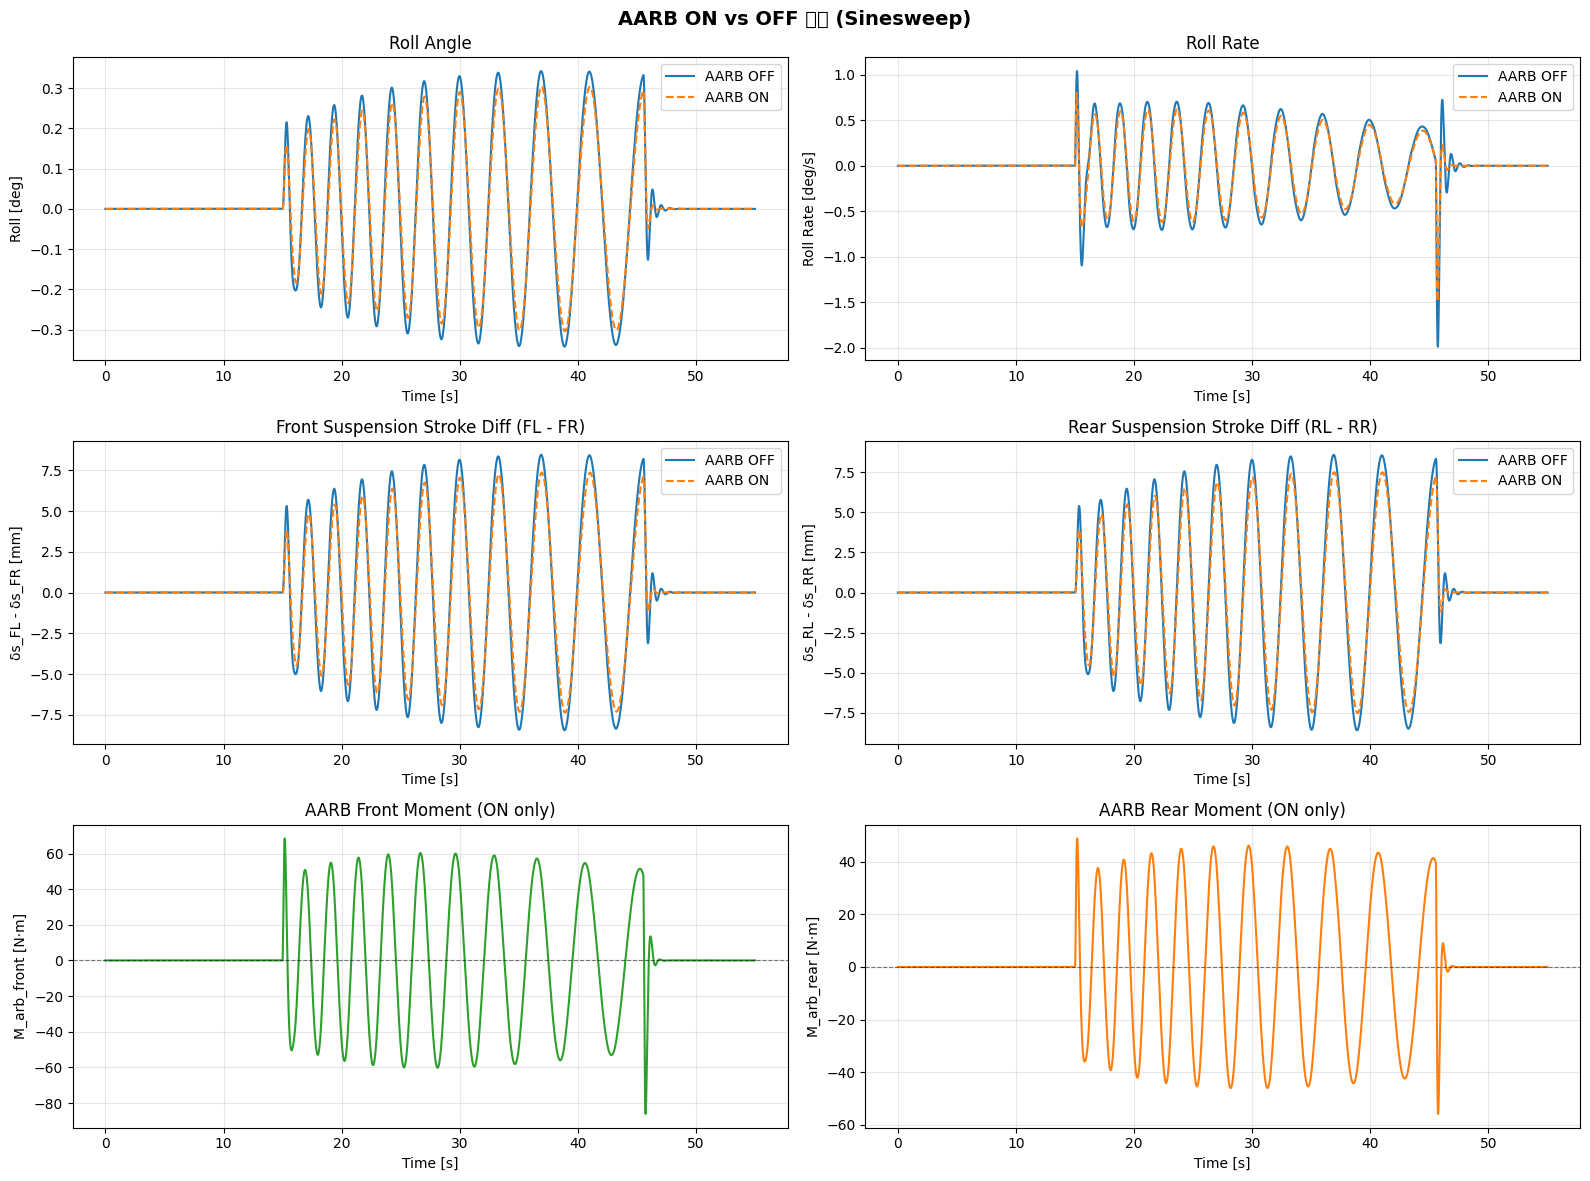

In [ ]:
# ==================== 플롯 ====================
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('AARB ON vs OFF Comparison(Sinesweep)', fontsize=14, fontweight='bold')

t = time

# 1. Roll angle
ax = axes[0, 0]
ax.plot(t, np.degrees(result_off['roll']), label='AARB OFF', linewidth=1.5)
ax.plot(t, np.degrees(result_on['roll']),  label='AARB ON',  linewidth=1.5, linestyle='--')
ax.set_ylabel('Roll [deg]')
ax.set_xlabel('Time [s]')
ax.set_title('Roll Angle')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Roll rate
ax = axes[0, 1]
ax.plot(t, np.degrees(result_off['roll_rate']), label='AARB OFF', linewidth=1.5)
ax.plot(t, np.degrees(result_on['roll_rate']),  label='AARB ON',  linewidth=1.5, linestyle='--')
ax.set_ylabel('Roll Rate [deg/s]')
ax.set_xlabel('Time [s]')
ax.set_title('Roll Rate')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. 전륜 스트로크 차 (FL - FR)
ax = axes[1, 0]
ax.plot(t, result_off['ds_front'] * 1000, label='AARB OFF', linewidth=1.5)
ax.plot(t, result_on['ds_front']  * 1000, label='AARB ON',  linewidth=1.5, linestyle='--')
ax.set_ylabel('δs_FL - δs_FR [mm]')
ax.set_xlabel('Time [s]')
ax.set_title('Front Suspension Stroke Diff (FL - FR)')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. 후륜 스트로크 차 (RL - RR)
ax = axes[1, 1]
ax.plot(t, result_off['ds_rear'] * 1000, label='AARB OFF', linewidth=1.5)
ax.plot(t, result_on['ds_rear']  * 1000, label='AARB ON',  linewidth=1.5, linestyle='--')
ax.set_ylabel('δs_RL - δs_RR [mm]')
ax.set_xlabel('Time [s]')
ax.set_title('Rear Suspension Stroke Diff (RL - RR)')
ax.legend()
ax.grid(True, alpha=0.3)

# 5. AARB 전륜 모멘트 (ON only)
ax = axes[2, 0]
ax.plot(t, result_on['M_arb_front'], color='tab:green', linewidth=1.5)
ax.set_ylabel('M_arb_front [N·m]')
ax.set_xlabel('Time [s]')
ax.set_title('AARB Front Moment (ON only)')
ax.axhline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
ax.grid(True, alpha=0.3)

# 6. AARB 후륜 모멘트 (ON only)
ax = axes[2, 1]
ax.plot(t, result_on['M_arb_rear'], color='tab:orange', linewidth=1.5)
ax.set_ylabel('M_arb_rear [N·m]')
ax.set_xlabel('Time [s]')
ax.set_title('AARB Rear Moment (ON only)')
ax.axhline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()